# Building the joint model: marginals, PITs, and a Gaussian copula

This is the data-and-fitting prequel to `4_copula_nco.ipynb`. Here we look at the 19 risky assets, fit a Student-$t$ marginal to each, transform to uniforms via the probability integral transform (PIT), and fit a Gaussian copula on the dependence. The fitted model is saved to `copula_model.pkl`; **`4_copula_nco.ipynb` loads that file** and uses the model for the NCO-vs-all-at-once portfolio comparison.

Data: the original VMLS price series (`vmls_portfolio_prices.csv`, exported from the Julia VMLS package) and the matching daily returns (`vmls_portfolio_returns.csv`). We work entirely on the **training set** (first 2000 daily returns / first 2001 price observations); the held-out test set is used only in the portfolio notebook.

*With thanks to Joe Schneider for the original NCO example.*

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

sns.set(style="whitegrid")

## Data

The price file has 2517 rows; `portfolio_data()` uses the first 2501 (→ 2500 returns). The training set is the first 2000 returns, derived from the first 2001 price rows. Columns 1–19 are risky stocks; column 20 is the risk-free asset, which the portfolio notebook holds out — we keep the 19 risky ones here.

In [2]:
prices_all  = pd.read_csv("vmls_portfolio_prices.csv").to_numpy()
returns_all = pd.read_csv("vmls_portfolio_returns.csv").to_numpy()

P  = prices_all[:2001, :19]    # training price levels (19 risky), 2001 rows
R  = returns_all[:2000, :19]   # training returns (19 risky), 2000 rows
p  = R.shape[1]
asset_names = [f"stock {j+1}" for j in range(p)]

print(f"training prices P : {P.shape}")
print(f"training returns R: {R.shape}")
# sanity: prices reproduce the stored returns
chk = (P[1:] - P[:-1]) / P[:-1]
print(f"price/return consistency (max abs diff): {np.max(np.abs(chk - R)):.2e}")

training prices P : (2001, 19)
training returns R: (2000, 19)
price/return consistency (max abs diff): 9.99e-17


## The 19 price series (training set)

Ten on the first chart, the remaining nine on the second. These are the original VMLS price levels, not a reconstructed index.

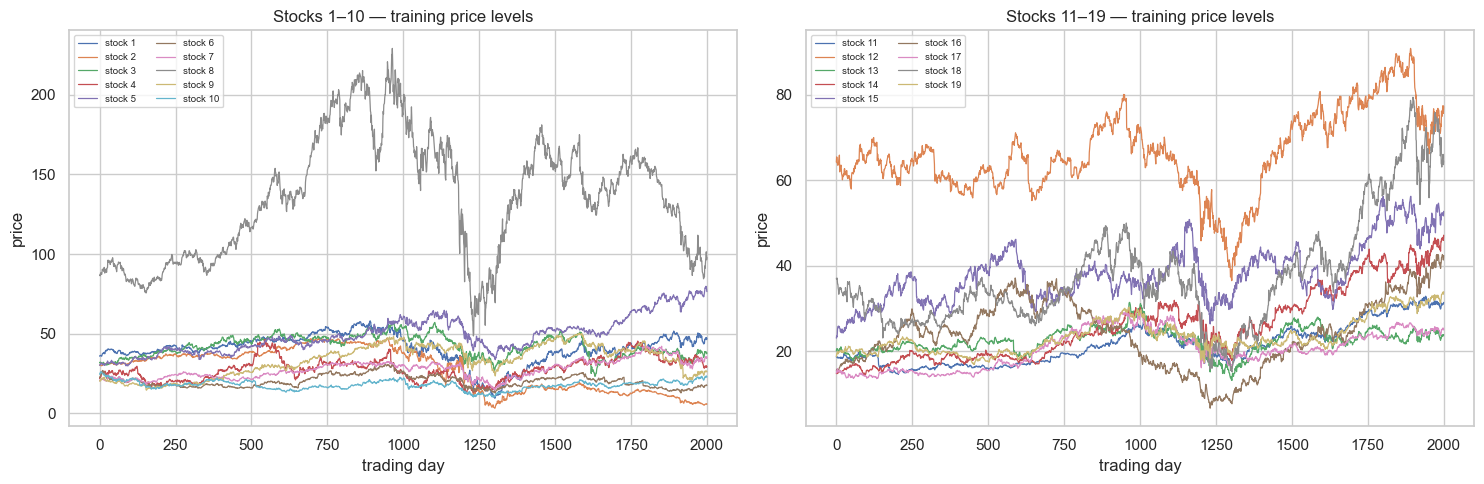

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for j in range(10):
    axes[0].plot(P[:, j], lw=.9, label=asset_names[j])
for j in range(10, p):
    axes[1].plot(P[:, j], lw=.9, label=asset_names[j])
axes[0].set_title("Stocks 1–10 — training price levels")
axes[1].set_title("Stocks 11–19 — training price levels")
for a in axes:
    a.set_xlabel("trading day"); a.set_ylabel("price")
    a.legend(fontsize=7, ncol=2, loc="upper left")
plt.tight_layout(); plt.show()

## Return distributions and Student-$t$ fits

We illustrate the marginal fitting on a representative sample of four assets — **stocks 1, 2, 3, 10** — the same set used for the PIT scatter below (stock 1 and 2 are the very fat-tailed pair; stock 10 is comparatively well-behaved). For each: the return histogram with the fitted Student-$t$ density overlaid, and the fitted CDF against the empirical CDF.

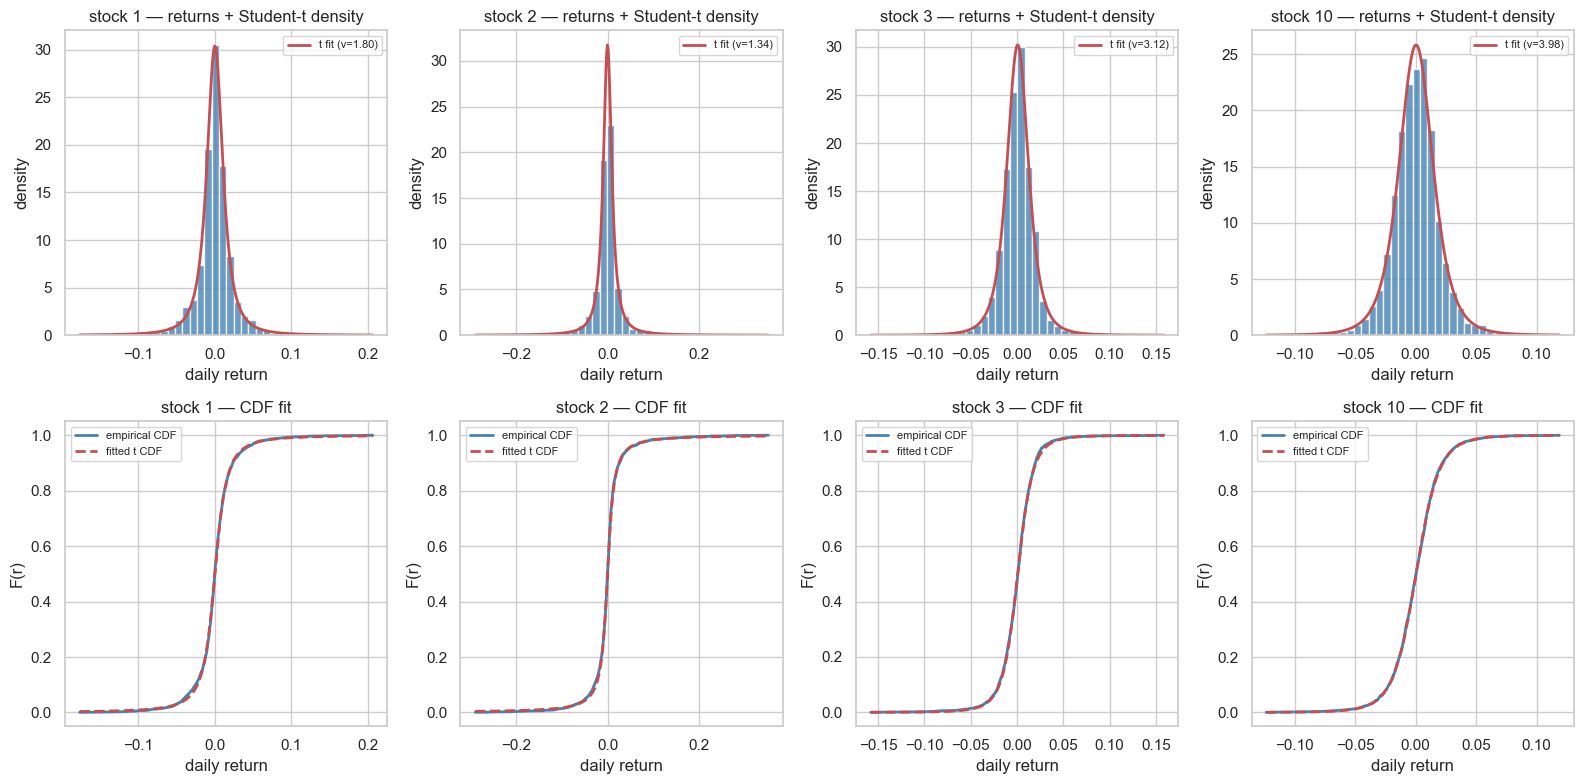

In [4]:
SAMPLE = [0, 1, 2, 9]                       # stocks 1, 2, 3, 10 (0-indexed)
marginals = [stats.t.fit(R[:, j]) for j in range(p)]   # (df, loc, scale) all 19

fig, axes = plt.subplots(2, len(SAMPLE), figsize=(16, 8))
for col, j in enumerate(SAMPLE):
    df, loc, scale = marginals[j]
    x = np.linspace(R[:, j].min(), R[:, j].max(), 400)

    ax = axes[0, col]
    ax.hist(R[:, j], bins=40, density=True, color="steelblue",
            edgecolor="white", alpha=.8)
    ax.plot(x, stats.t.pdf(x, df, loc, scale), "r-", lw=2,
            label=f"t fit (ν={df:.2f})")
    ax.set_title(f"{asset_names[j]} — returns + Student-t density")
    ax.set_xlabel("daily return"); ax.set_ylabel("density"); ax.legend(fontsize=8)

    ax = axes[1, col]
    xs = np.sort(R[:, j])
    ax.plot(xs, np.arange(1, len(xs) + 1) / len(xs), color="steelblue",
            lw=2, label="empirical CDF")
    ax.plot(x, stats.t.cdf(x, df, loc, scale), "r--", lw=2,
            label="fitted t CDF")
    ax.set_title(f"{asset_names[j]} — CDF fit")
    ax.set_xlabel("daily return"); ax.set_ylabel("F(r)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Fitted Student-$t$ parameters (all 19 assets)

The degrees of freedom are the headline: every asset has $\nu < 5$ (median $\approx 3$), i.e. extremely fat tails — none is close to Gaussian ($\nu\to\infty$). This is *why* the portfolio notebook needs the per-asset tail clip on simulated draws.

In [5]:
marg_tbl = pd.DataFrame(marginals, columns=["df (ν)", "loc", "scale"],
                        index=asset_names)
nu = marg_tbl["df (ν)"]
print(f"df summary: min={nu.min():.2f}  median={nu.median():.2f}  "
      f"mean={nu.mean():.2f}  max={nu.max():.2f}")
print(f"assets with ν < 4: {(nu < 4).sum()}/19   |   ν < 10: {(nu < 10).sum()}/19   "
      f"|   ν > 30 (~Gaussian): {(nu > 30).sum()}/19")
marg_tbl.round(5)

df summary: min=1.34  median=3.12  mean=3.11  max=4.60
assets with ν < 4: 16/19   |   ν < 10: 19/19   |   ν > 30 (~Gaussian): 0/19


,df (ν),loc,scale
stock 1,1.79756,0.00038,0.01148
stock 2,1.34464,-0.00018,0.01055
stock 3,3.11874,0.00076,0.01220
stock 4,4.60100,0.00016,0.02175
stock 5,4.10474,0.00039,0.01134
stock 6,3.35239,0.00029,0.01353
stock 7,2.94306,0.00011,0.01158
stock 8,2.42335,0.00028,0.01393
stock 9,3.17173,0.00054,0.01281
stock 10,3.97836,0.00028,0.01451


## Probability integral transform (PITs)

Push each asset's training returns through its fitted $t$ CDF; if the marginal fits well each column is $\approx$ Uniform(0,1). A 4×4 pairplot for the sample assets: the **diagonal** is each asset's PIT histogram (the marginal-uniformity check) and the **off-diagonal** panels are pairwise PIT scatters (uniform margins, so any structure is pure dependence — the object the copula models).

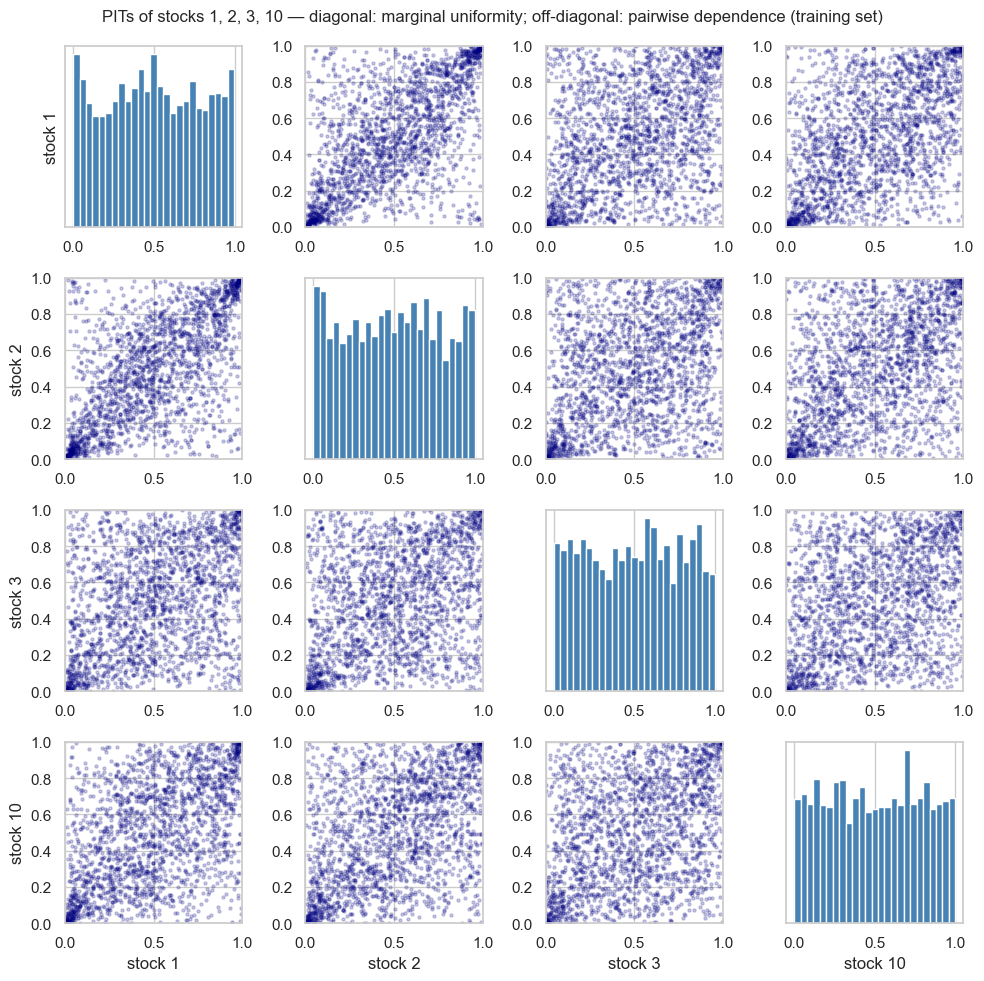

In [6]:
U = np.column_stack([stats.t.cdf(R[:, j], *marginals[j]) for j in range(p)])
U = np.clip(U, 1e-6, 1 - 1e-6)

m = len(SAMPLE)
fig, axes = plt.subplots(m, m, figsize=(10, 10))
for a in range(m):
    for b in range(m):
        ax = axes[a, b]
        ja, jb = SAMPLE[a], SAMPLE[b]
        if a == b:
            ax.hist(U[:, ja], bins=25, color="steelblue", edgecolor="white")
            ax.set_yticks([])
        else:
            ax.scatter(U[:, jb], U[:, ja], s=5, alpha=0.2, color="navy")
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        if a == m - 1: ax.set_xlabel(asset_names[SAMPLE[b]])
        if b == 0:     ax.set_ylabel(asset_names[SAMPLE[a]])
fig.suptitle("PITs of stocks 1, 2, 3, 10 — diagonal: marginal uniformity; "
             "off-diagonal: pairwise dependence (training set)", fontsize=12)
fig.tight_layout(); plt.show()

## Gaussian copula

A Gaussian copula's only parameter is a correlation matrix $P$, estimated in closed form: map the PITs to normal scores $z = \Phi^{-1}(u)$ and take their sample correlation (a small eigenvalue floor keeps $P$ positive-definite). We use a Gaussian copula because a full 19-dimensional $t$-copula MLE is numerically intractable, and the family is immaterial to the portfolio lesson (the instability is in the optimization step).

In [7]:
Z = stats.norm.ppf(U)
P_corr = np.corrcoef(Z, rowvar=False)
ev, V = np.linalg.eigh(P_corr)
P_corr = V @ np.diag(np.clip(ev, 1e-10, None)) @ V.T
d = np.sqrt(np.diag(P_corr))
P_corr = P_corr / np.outer(d, d)
chol_P = np.linalg.cholesky(P_corr)

print(f"Gaussian copula: 19×19 correlation matrix, "
      f"condition number {np.linalg.cond(P_corr):.1f}")
print("top-left 5×5 of the dependence matrix:")
print(np.round(P_corr[:5, :5], 3))

Gaussian copula: 19×19 correlation matrix, condition number 36.7
top-left 5×5 of the dependence matrix:
[[1.    0.66  0.418 0.412 0.467]
 [0.66  1.    0.393 0.339 0.401]
 [0.418 0.393 1.    0.341 0.301]
 [0.412 0.339 0.341 1.    0.371]
 [0.467 0.401 0.301 0.371 1.   ]]


## Save the fitted model

We pickle everything `4_copula_nco.ipynb` needs to simulate from the all-19 model and to refit per-cluster sub-models: the fitted marginals, the copula Cholesky factor, and the per-asset $2\times$-historical clip used on simulated draws. **Run this notebook before `4_copula_nco.ipynb`.**

In [8]:
CAP = 2.0 * np.max(np.abs(R), axis=0)      # per-asset symmetric clip, length 19

model = {
    "asset_names": asset_names,
    "marginals":   marginals,        # list of (df, loc, scale), 19 assets
    "chol_P":      chol_P,           # Cholesky of the 19×19 copula correlation
    "P_corr":      P_corr,
    "cap":         CAP,              # per-asset 2× max|train| clip
    "n_assets":    p,
    "note":        "Fitted on training set (first 2000 returns, 19 risky assets) "
                   "by 3_copula_model_fitting.ipynb",
}
with open("copula_model.pkl", "wb") as fh:
    pickle.dump(model, fh)

print("wrote copula_model.pkl")
print("keys:", list(model.keys()))
print(f"clip range: [{CAP.min():.3f}, {CAP.max():.3f}]")

wrote copula_model.pkl
keys: ['asset_names', 'marginals', 'chol_P', 'P_corr', 'cap', 'n_assets', 'note']
clip range: [0.198, 0.704]


Continue to **`4_copula_nco.ipynb`**, which loads `copula_model.pkl` and runs the NCO-vs-all-at-once portfolio comparison.